## LOADING DATASET-2

In [1]:
import pandas as pd
path1= "C:\\Users\\sweth\\OneDrive\\Desktop\\HEP_2.csv"
data= pd.read_csv(path1)

In [2]:
data.columns= data.columns.str.upper().str.replace('_', ' ').str.replace('CLASS', 'Class').str.replace('PALABLE', 'PALPABLE')

In [3]:
print('the data dimensions are (rows, cols): ', data.shape)

the data dimensions are (rows, cols):  (142, 20)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Class            142 non-null    int64  
 1   AGE              142 non-null    int64  
 2   SEX              142 non-null    int64  
 3   STEROID          142 non-null    int64  
 4   ANTIVIRALS       142 non-null    int64  
 5   FATIGUE          142 non-null    int64  
 6   MALAISE          142 non-null    int64  
 7   ANOREXIA         142 non-null    int64  
 8   LIVER BIG        142 non-null    int64  
 9   LIVER FIRM       142 non-null    int64  
 10  SPLEEN PALPABLE  142 non-null    int64  
 11  SPIDERS          142 non-null    int64  
 12  ASCITES          142 non-null    int64  
 13  VARICES          142 non-null    int64  
 14  BILIRUBIN        142 non-null    float64
 15  ALK PHOSPHATE    142 non-null    int64  
 16  SGOT             142 non-null    int64  
 17  ALBUMIN         

## CHECKING FOR MISSING VALUES

In [5]:
data.isnull().sum()

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER BIG          0
LIVER FIRM         0
SPLEEN PALPABLE    0
SPIDERS            0
ASCITES            0
VARICES            0
BILIRUBIN          0
ALK PHOSPHATE      0
SGOT               0
ALBUMIN            0
PROTIME            0
HISTOLOGY          0
dtype: int64

In [6]:
data.replace('?', pd.NA, inplace=True)

In [7]:
data.isnull().sum()

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER BIG          0
LIVER FIRM         0
SPLEEN PALPABLE    0
SPIDERS            0
ASCITES            0
VARICES            0
BILIRUBIN          0
ALK PHOSPHATE      0
SGOT               0
ALBUMIN            0
PROTIME            0
HISTOLOGY          0
dtype: int64

In [8]:
data= data.dropna()

## CHECKING FOR OUTLIERS IN AGE AND REMOVING SAMPLES WITH AGE 70+

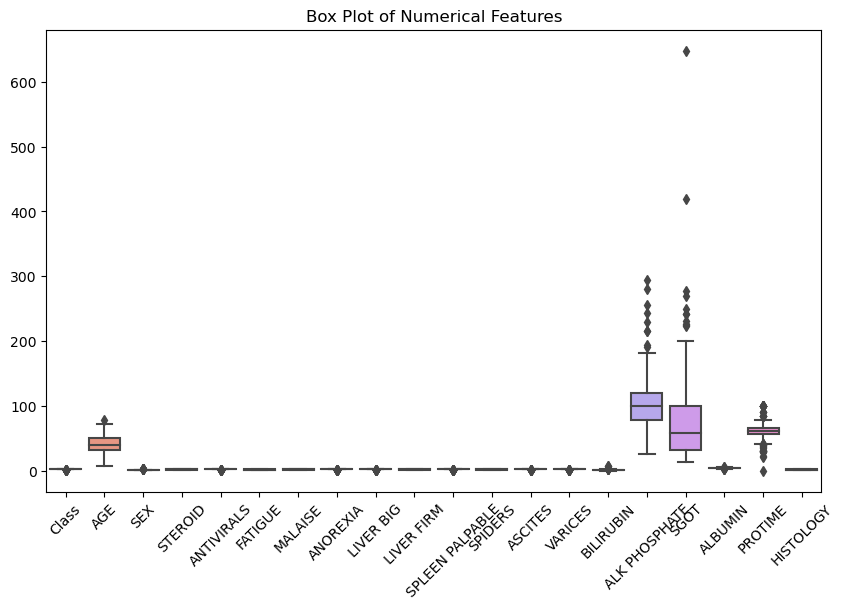

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

In [10]:
import pandas as pd
Q1 = data['AGE'].quantile(0.25)
Q3 = data['AGE'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1 * IQR
outliers = data[data['AGE'] > upper_bound]
outliers

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.7,96,32,4.00,61,1
107,2,69,2,2,2,1,2,2,2,2,2,2,2,2,3.2,119,136,3.81,61,2
123,2,72,1,2,1,1,2,2,2,1,2,2,2,2,1.0,115,52,3.40,50,2


In [11]:
data_sorted_by_age = data.sort_values(by='AGE', ascending=False)
data_sorted_by_age

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.7,96,32,4.00,61,1
123,2,72,1,2,1,1,2,2,2,1,2,2,2,2,1.0,115,52,3.40,50,2
107,2,69,2,2,2,1,2,2,2,2,2,2,2,2,3.2,119,136,3.81,61,2
15,2,66,1,2,2,1,2,2,2,2,2,2,2,2,1.2,102,53,4.30,61,1
37,2,65,1,2,2,1,1,2,2,1,1,1,1,2,0.3,180,53,2.90,74,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,2,22,2,2,1,1,2,2,2,2,2,2,2,2,0.9,48,20,4.20,64,1
35,2,20,2,1,2,1,1,1,1,1,1,1,2,2,2.3,150,68,3.90,61,1
112,2,20,1,1,2,1,1,1,2,2,2,1,1,2,1.0,160,118,2.90,23,2
135,2,20,1,1,2,2,2,2,2,2,2,2,2,2,0.9,89,152,4.00,61,2


In [12]:
data= data[data['AGE']<70]

In [13]:
data.shape

(140, 20)

## FEATURE SELECTION BASED ON CORRELATION- removing features with <=0.1 correlation

In [14]:
data= data.apply(pd.to_numeric)

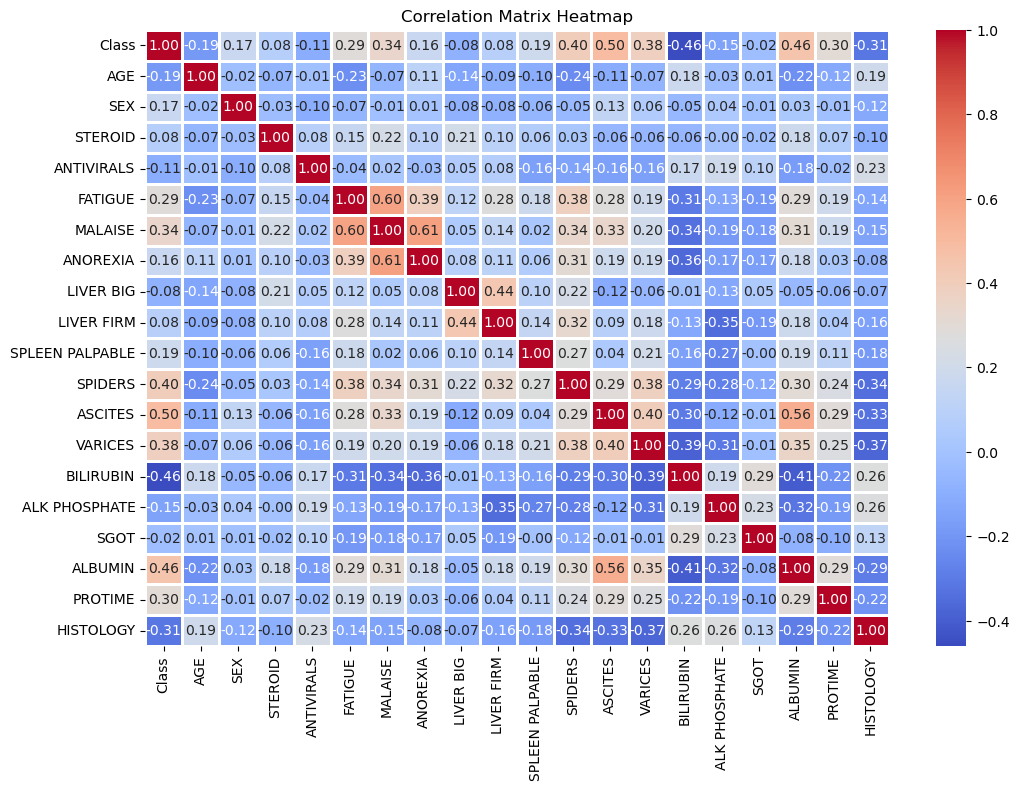

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix= data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=2)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [16]:
highly_correlated_features= [ 'AGE', 'SEX', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 
             'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 
             'BILIRUBIN', 'ALK PHOSPHATE', 'ALBUMIN', 'PROTIME', 'HISTOLOGY']
required_features= highly_correlated_features.append('Class')
data= pd.DataFrame(data= data.drop(columns=data.columns.difference(highly_correlated_features)))

## HANDLING THE IMBALANCE IN DATASET BY USING OVERSAMPLING TECHNIQUES- Borderline SMOTE, Random OverSampling and SMOTE

In [17]:
data['Class'].value_counts()

2    114
1     26
Name: Class, dtype: int64

In [18]:
DF= data
X = DF.drop(columns=['Class'])
y = DF['Class']

In [19]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE, SMOTE
from sklearn.datasets import make_classification
def oversampling(X, y, oversample_method, method_name):
    print(f"Original class distribution for {method_name}:", Counter(y))
    X_resampled, y_resampled = oversample_method.fit_resample(X, y)
    print(f"Resampled class distribution for {method_name}:", Counter(y_resampled))
    resampled_data = pd.DataFrame(data=X_resampled, columns=X.columns)
    resampled_data['Class'] = y_resampled
    resampled_data.to_csv(f'hepatitisss_{method_name}.csv', index=False) 
oversampling(X.copy(), y.copy(), RandomOverSampler(random_state=42), "ROS")
oversampling(X.copy(), y.copy(), BorderlineSMOTE(random_state=123), "Borderline_SMOTE")
oversampling(X.copy(), y.copy(), SMOTE(random_state=42), "SMOTE")

Original class distribution for ROS: Counter({2: 114, 1: 26})
Resampled class distribution for ROS: Counter({2: 114, 1: 114})
Original class distribution for Borderline_SMOTE: Counter({2: 114, 1: 26})
Resampled class distribution for Borderline_SMOTE: Counter({2: 114, 1: 114})
Original class distribution for SMOTE: Counter({2: 114, 1: 26})
Resampled class distribution for SMOTE: Counter({2: 114, 1: 114})


## LOADING THE DATASETS AND SPLITTING INTO TRAIN AND TEST- 80:20

In [20]:
import pandas as pd
path1= r"C:\Users\sweth\ml_hep\hepatitisss_Borderline_SMOTE.csv"
path2= r"C:\Users\sweth\ml_hep\hepatitisss_ROS.csv"
path3= r"C:\Users\sweth\ml_hep\hepatitisss_SMOTE.csv"

## BORDERLINE OVERSAMPLED DATASET

In [21]:
data1= pd.read_csv(path1)
df= data1
X = df.drop(columns=['Class'])
y = df['Class']
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

def perform_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search.best_score_)
    return grid_search.best_estimator_

print('\nLogistic Regression (LR)')
lr_param_grid = {
    'max_iter': [100, 500, 1000, 10000], 
    'solver': ['lbfgs', 'liblinear', 'saga','newton-cholesky'],
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'random_state': [1, 7, 42]
}
lr = LogisticRegression(random_state=42)
best_lr = perform_grid_search(lr, lr_param_grid, X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print('\nK-Nearest Neighbors (KNN):')
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
best_knn = perform_grid_search(knn, knn_param_grid, X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

print('\nSupport Vector Machine (SVM):')
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [1, 7, 42]
}
svm = SVC(random_state=42)
best_svm = perform_grid_search(svm, svm_param_grid, X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

random_forest = RandomForestClassifier(random_state=1)
grid_search = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=10, scoring='accuracy', n_jobs=1, verbose=0)
grid_search.fit(X_train_scaled, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Accuracy:', grid_search.best_score_)
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_rf)
print('Test Accuracy:', test_accuracy)
print(classification_report(y_test, y_pred_rf))


Logistic Regression (LR)
Fitting 10 folds for each of 192 candidates, totalling 1920 fits


C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
840 fits failed out of a total of 1920.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1172, in fit
    solver

Best Parameters: {'max_iter': 100, 'penalty': None, 'random_state': 1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.87953216374269
TEST accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        21

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46


K-Nearest Neighbors (KNN):
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9339181286549708
TEST accuracy: 0.9347826086956522
              precision    recall  f1-score   support

           1       0.92      0.96      0.94        25
           2       0.95      0.90      0.93        21

    accuracy                           0.93        46
   macro avg       0.94      0.93      0.93        46
weighted 


Logistic Regression (LR)
CV accuracy: 0.87953216374269
TEST accuracy: 1.0


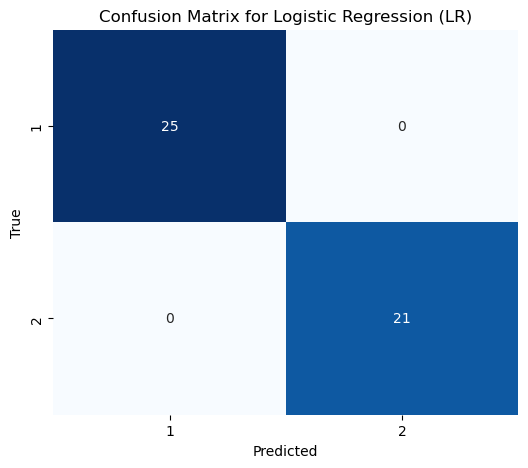


K-Nearest Neighbors (KNN)
CV accuracy: 0.9339181286549708
TEST accuracy: 0.9347826086956522


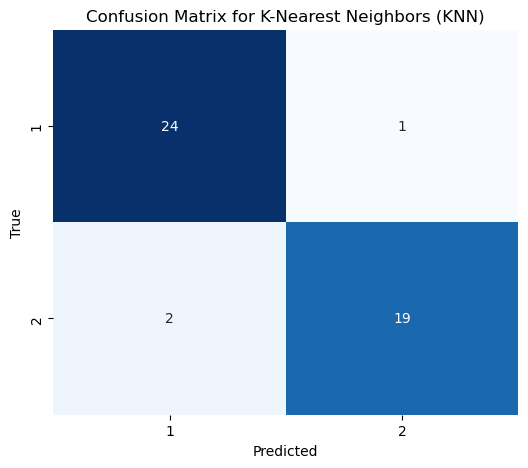


Support Vector Machine (SVM)
CV accuracy: 0.9283625730994152
TEST accuracy: 0.9782608695652174


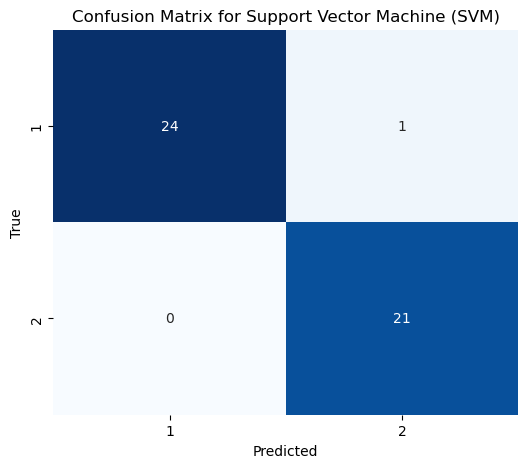


Random Forest
CV accuracy: 0.8906432748538011
TEST accuracy: 0.9782608695652174


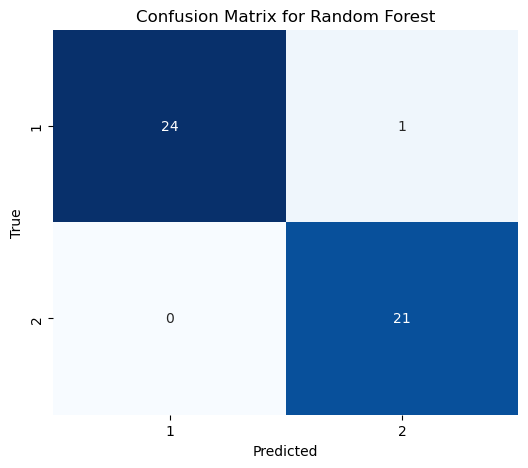


Results:
Classifier               Accuracy  CV Accuracy Sensitivity Specificity Precision   F-measure   
Logistic Regression (LR) 100.00    87.95       100.00      100.00      100.00      100.00      
K-Nearest Neighbors (KNN)93.48     93.39       93.24       93.24       93.65       93.40       
Support Vector Machine (SVM)97.83     92.84       98.00       98.00       97.73       97.82       
Random Forest            97.83     89.06       98.00       98.00       97.73       97.82       


In [25]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
cv = StratifiedKFold(n_splits=10)
classifiers = [
    ('Logistic Regression (LR)', LogisticRegression(max_iter=100, solver='lbfgs', penalty=None, verbose=0, random_state=1)),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier(n_neighbors=3, weights= 'uniform')),
    ('Support Vector Machine (SVM)', SVC(C=1, gamma=0.1, kernel='rbf', random_state=1)),
    ('Random Forest', RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=5, n_estimators=100, bootstrap=False, random_state=1))
]
results = []
for name, clf in classifiers:
    print(f'\n{name}')
    ac_cv = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    print('CV accuracy:', ac_cv)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    ac_test = accuracy_score(y_test, y_pred)
    print('TEST accuracy:', ac_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []
    for i in range(len(cm)):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))
    specificity = np.mean(specificity_per_class)
    results.append((name, ac_test, ac_cv, recall, specificity, precision, f1))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
print('\nResults:')
print('{:<25}{:<10}{:<12}{:<12}{:<12}{:<12}{:<12}'.format('Classifier', 'Accuracy', 'CV Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F-measure'))
for result in results:
    name, ac_test, ac_cv, recall, specificity, precision, f1 = result
    print('{:<25}{:<10.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}'.format(name, ac_test*100, ac_cv*100, recall*100, specificity*100, precision*100, f1*100))
plt.show()


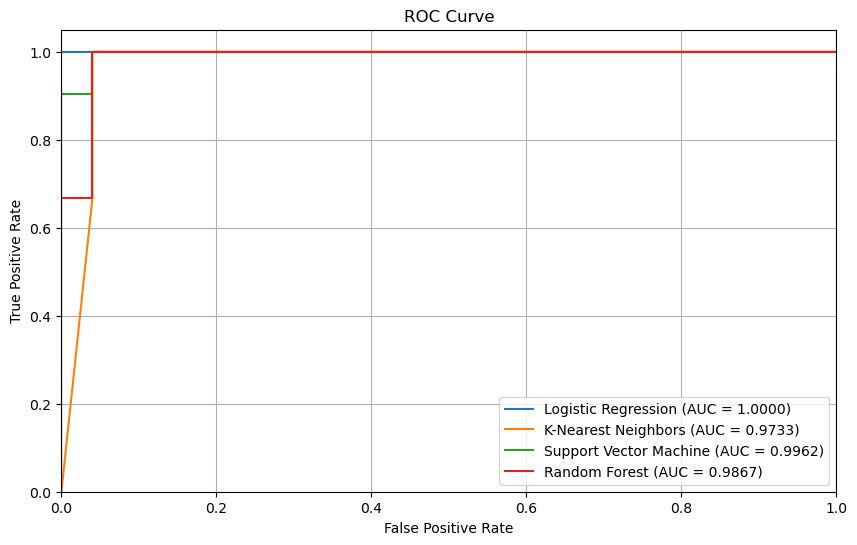

In [26]:
def plot_roc_curve(model, name, X_train_scaled, y_train, X_test_scaled, y_test):
    """Plots the ROC curve for a given model."""
    model.fit(X_train_scaled, y_train)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=2)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.legend(loc='lower right')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.grid(True)
lr = LogisticRegression(max_iter=100, solver='lbfgs', penalty= None , verbose=0, random_state=1)
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform')
svm = SVC(C=1, gamma=0.1, kernel='rbf', random_state=1, probability=True)
rf = RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=5, n_estimators=100, bootstrap=False, random_state=1)
plt.figure(figsize=(10, 6))
plot_roc_curve(lr, 'Logistic Regression', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(knn, 'K-Nearest Neighbors', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(svm, 'Support Vector Machine', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(rf, 'Random Forest', X_train_scaled, y_train, X_test_scaled, y_test)
plt.show()  

## RANDOM OVERSAMPLING OVERSAMPLED DATASET

In [27]:
data2= pd.read_csv(path2)
df2=data2
X = df2.drop(columns=['Class'])
y = df2['Class']
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

def perform_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search.best_score_)
    return grid_search.best_estimator_

print('\nLogistic Regression (LR)')
lr_param_grid = {
    'max_iter': [100, 500, 1000, 10000], 
    'solver': ['lbfgs', 'liblinear', 'saga','newton-cholesky'],
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'random_state': [1, 7, 42]
}
lr = LogisticRegression(random_state=42)
best_lr = perform_grid_search(lr, lr_param_grid, X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print('\nK-Nearest Neighbors (KNN):')
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
best_knn = perform_grid_search(knn, knn_param_grid, X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

print('\nSupport Vector Machine (SVM):')
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [1, 7, 42]
}
svm = SVC(random_state=42)
best_svm = perform_grid_search(svm, svm_param_grid, X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

random_forest = RandomForestClassifier(random_state=1)
grid_search = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=10, scoring='accuracy', n_jobs=1, verbose=0)
grid_search.fit(X_train_scaled, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Accuracy:', grid_search.best_score_)
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_rf)
print('Test Accuracy:', test_accuracy)
print(classification_report(y_test, y_pred_rf))


Logistic Regression (LR)
Fitting 10 folds for each of 192 candidates, totalling 1920 fits


C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
840 fits failed out of a total of 1920.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1172, in fit
    solver

Best Parameters: {'max_iter': 100, 'penalty': 'l1', 'random_state': 1, 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8470760233918128
TEST accuracy: 0.8913043478260869
              precision    recall  f1-score   support

           1       0.88      0.92      0.90        25
           2       0.90      0.86      0.88        21

    accuracy                           0.89        46
   macro avg       0.89      0.89      0.89        46
weighted avg       0.89      0.89      0.89        46


K-Nearest Neighbors (KNN):
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9394736842105263
TEST accuracy: 0.9565217391304348
              precision    recall  f1-score   support

           1       0.93      1.00      0.96        25
           2       1.00      0.90      0.95        21

    accuracy                           0.96        46
   macro avg       0.96      0.95      0.9


Logistic Regression (LR)
CV accuracy: 0.8470760233918128
TEST accuracy: 0.8913043478260869


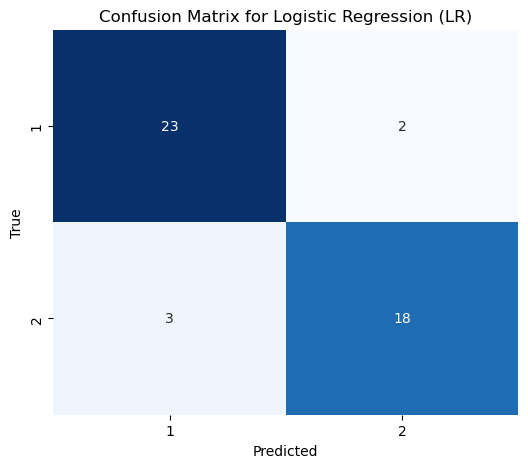


K-Nearest Neighbors (KNN)
CV accuracy: 0.9394736842105263
TEST accuracy: 0.9565217391304348


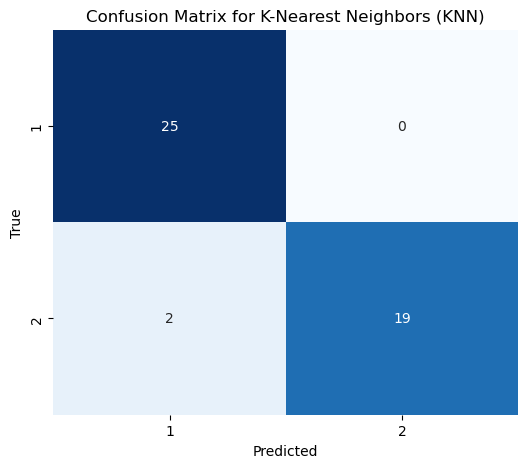


Support Vector Machine (SVM)
CV accuracy: 0.9777777777777779
TEST accuracy: 1.0


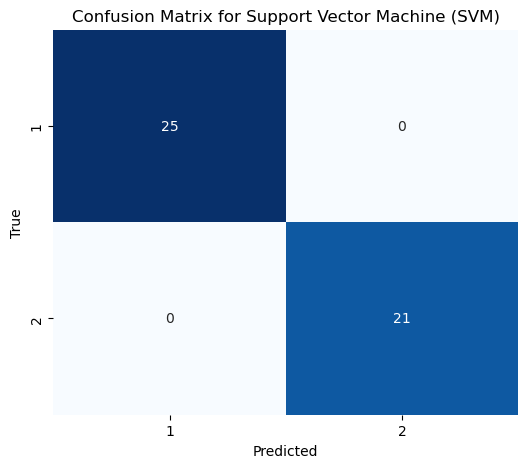


Random Forest
CV accuracy: 0.9450292397660819
TEST accuracy: 1.0


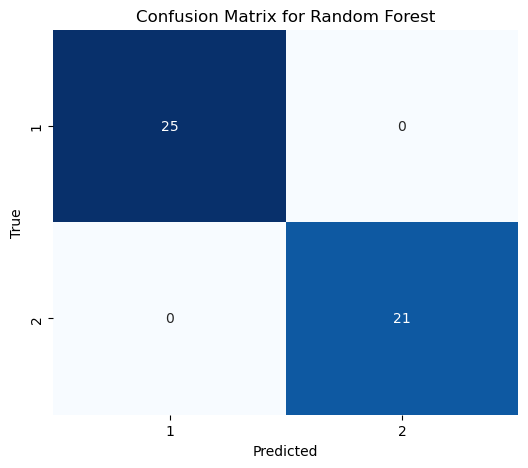


Results:
Classifier               Accuracy  CV Accuracy Sensitivity Specificity Precision   F-measure   
Logistic Regression (LR) 89.13     84.71       88.86       88.86       89.23       89.00       
K-Nearest Neighbors (KNN)95.65     93.95       95.24       95.24       96.30       95.58       
Support Vector Machine (SVM)100.00    97.78       100.00      100.00      100.00      100.00      
Random Forest            100.00    94.50       100.00      100.00      100.00      100.00      


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
cv = StratifiedKFold(n_splits=10)
classifiers = [
    ('Logistic Regression (LR)', LogisticRegression(max_iter=100, solver='liblinear', penalty='l1', verbose=0, random_state=1)),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier(n_neighbors=1, weights= 'uniform')),
    ('Support Vector Machine (SVM)', SVC(C=1, gamma=1, kernel='rbf', random_state=1)),
    ('Random Forest', RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=5, n_estimators=200, bootstrap=False, random_state=1))
]
results = []
for name, clf in classifiers:
    print(f'\n{name}')
    ac_cv = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    print('CV accuracy:', ac_cv)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    ac_test = accuracy_score(y_test, y_pred)
    print('TEST accuracy:', ac_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []
    for i in range(len(cm)):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))
    specificity = np.mean(specificity_per_class)
    results.append((name, ac_test, ac_cv, recall, specificity, precision, f1))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
print('\nResults:')
print('{:<25}{:<10}{:<12}{:<12}{:<12}{:<12}{:<12}'.format('Classifier', 'Accuracy', 'CV Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F-measure'))
for result in results:
    name, ac_test, ac_cv, recall, specificity, precision, f1 = result
    print('{:<25}{:<10.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}'.format(name, ac_test*100, ac_cv*100, recall*100, specificity*100, precision*100, f1*100))
plt.show()


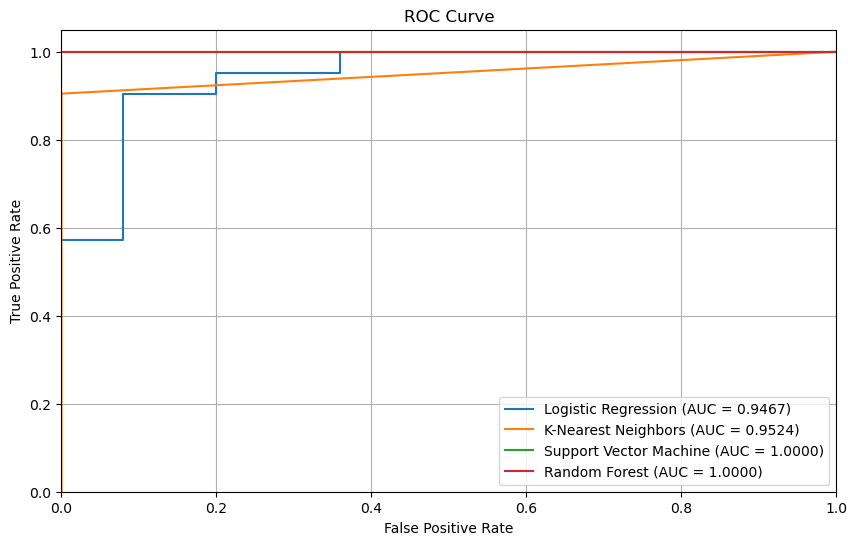

In [30]:
def plot_roc_curve(model, name, X_train_scaled, y_train, X_test_scaled, y_test):
    """Plots the ROC curve for a given model."""
    model.fit(X_train_scaled, y_train)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=2)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.legend(loc='lower right')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.grid(True)
lr = LogisticRegression(max_iter=100, solver='liblinear', penalty='l1', verbose=0, random_state=1)
knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
svm = SVC(C=1, gamma=1, kernel='rbf', random_state=1, probability=True) 
rf = RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=5, n_estimators=200, bootstrap=True, random_state=1)
plt.figure(figsize=(10, 6))
plot_roc_curve(lr, 'Logistic Regression', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(knn, 'K-Nearest Neighbors', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(svm, 'Support Vector Machine', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(rf, 'Random Forest', X_train_scaled, y_train, X_test_scaled, y_test)
plt.show()  

## SMOTE OVERSAMPLED DATASET

In [31]:
data3= pd.read_csv(path3)
df3=data3
X = df3.drop(columns=['Class'])
y = df3['Class']
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

def perform_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation Accuracy:', grid_search.best_score_)
    return grid_search.best_estimator_

print('\nLogistic Regression (LR)')
lr_param_grid = {
    'max_iter': [100, 500, 1000, 10000], 
    'solver': ['lbfgs', 'liblinear', 'saga','newton-cholesky'],
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'random_state': [1, 7, 42]
}
lr = LogisticRegression(random_state=42)
best_lr = perform_grid_search(lr, lr_param_grid, X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print('\nK-Nearest Neighbors (KNN):')
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
best_knn = perform_grid_search(knn, knn_param_grid, X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

print('\nSupport Vector Machine (SVM):')
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [1, 7, 42]
}
svm = SVC(random_state=42)
best_svm = perform_grid_search(svm, svm_param_grid, X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
print('TEST accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

random_forest = RandomForestClassifier(random_state=1)
grid_search = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=10, scoring='accuracy', n_jobs=1, verbose=0)
grid_search.fit(X_train_scaled, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Accuracy:', grid_search.best_score_)
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_rf)
print('Test Accuracy:', test_accuracy)
print(classification_report(y_test, y_pred_rf))


Logistic Regression (LR)
Fitting 10 folds for each of 192 candidates, totalling 1920 fits


C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
840 fits failed out of a total of 1920.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sweth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1172, in fit
    solver

Best Parameters: {'max_iter': 100, 'penalty': 'l1', 'random_state': 1, 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8850877192982456
TEST accuracy: 0.9347826086956522
              precision    recall  f1-score   support

           1       0.92      0.96      0.94        25
           2       0.95      0.90      0.93        21

    accuracy                           0.93        46
   macro avg       0.94      0.93      0.93        46
weighted avg       0.94      0.93      0.93        46


K-Nearest Neighbors (KNN):
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9175438596491228
TEST accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           1       0.85      0.92      0.88        25
           2       0.89      0.81      0.85        21

    accuracy                           0.87        46
   macro avg       0.87      0.86      0.8


Logistic Regression (LR)
CV accuracy: 0.8850877192982456
TEST accuracy: 0.9347826086956522


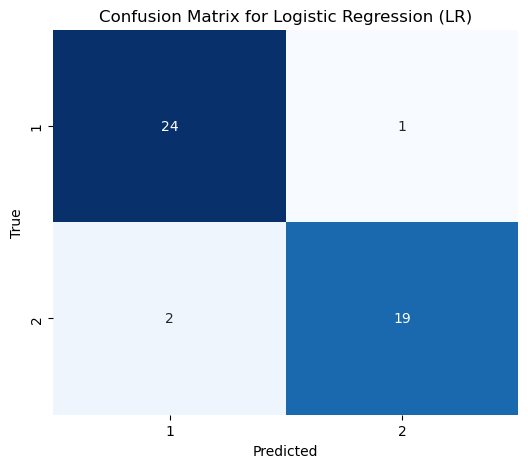


K-Nearest Neighbors (KNN)
CV accuracy: 0.9175438596491228
TEST accuracy: 0.8695652173913043


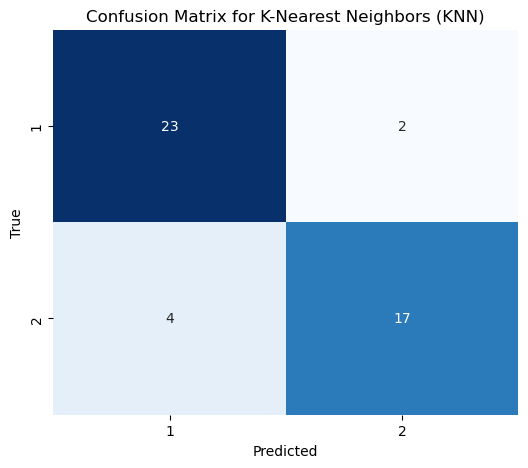


Support Vector Machine (SVM)
CV accuracy: 0.9122807017543859
TEST accuracy: 0.9347826086956522


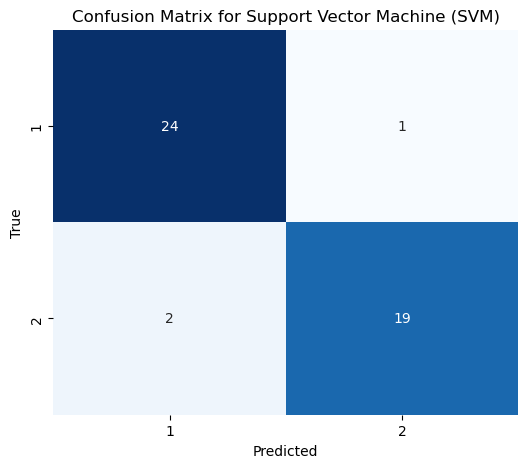


Random Forest
CV accuracy: 0.9014619883040936
TEST accuracy: 0.9782608695652174


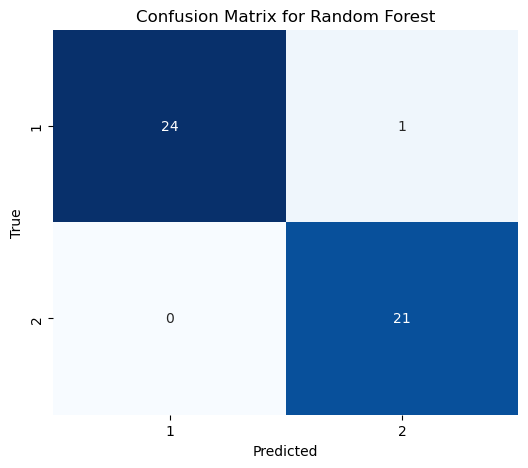


Results:
Classifier               Accuracy  CV Accuracy Sensitivity Specificity Precision   F-measure   
Logistic Regression (LR) 93.48     88.51       93.24       93.24       93.65       93.40       
K-Nearest Neighbors (KNN)86.96     91.75       86.48       86.48       87.33       86.73       
Support Vector Machine (SVM)93.48     91.23       93.24       93.24       93.65       93.40       
Random Forest            97.83     90.15       98.00       98.00       97.73       97.82       


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
cv = StratifiedKFold(n_splits=10)
classifiers = [
    ('Logistic Regression (LR)', LogisticRegression(max_iter=100, solver='liblinear', penalty='l1', verbose=0, random_state=1)),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier(n_neighbors=1, weights= 'uniform')),
    ('Support Vector Machine (SVM)', SVC(C=10, gamma=0.1, kernel='rbf', random_state=1)),
    ('Random Forest', RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=2, n_estimators=50, bootstrap=False, random_state=1))
]
results = []
for name, clf in classifiers:
    print(f'\n{name}')
    ac_cv = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    print('CV accuracy:', ac_cv)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    ac_test = accuracy_score(y_test, y_pred)
    print('TEST accuracy:', ac_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []
    for i in range(len(cm)):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))
    specificity = np.mean(specificity_per_class)
    results.append((name, ac_test, ac_cv, recall, specificity, precision, f1))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
print('\nResults:')
print('{:<25}{:<10}{:<12}{:<12}{:<12}{:<12}{:<12}'.format('Classifier', 'Accuracy', 'CV Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F-measure'))
for result in results:
    name, ac_test, ac_cv, recall, specificity, precision, f1 = result
    print('{:<25}{:<10.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}{:<12.2f}'.format(name, ac_test*100, ac_cv*100, recall*100, specificity*100, precision*100, f1*100))
plt.show()


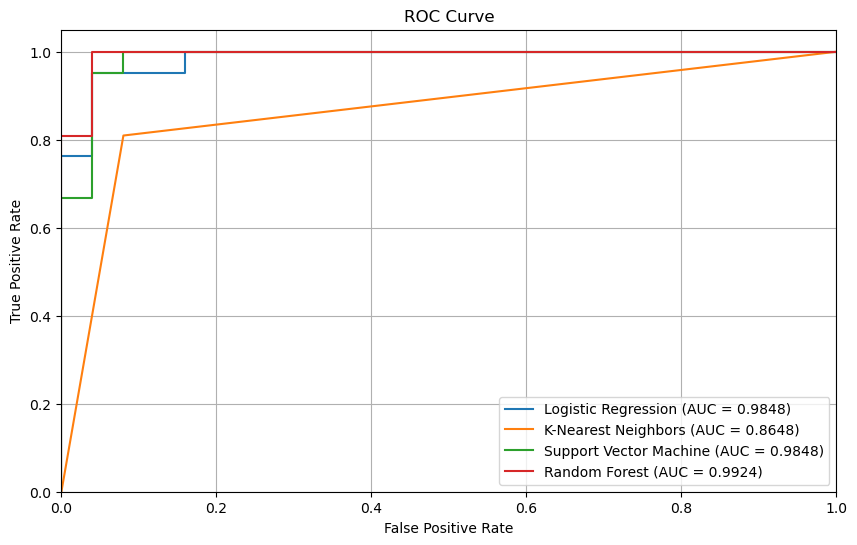

In [34]:
def plot_roc_curve(model, name, X_train_scaled, y_train, X_test_scaled, y_test):
    """Plots the ROC curve for a given model."""
    model.fit(X_train_scaled, y_train)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=2) 
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.legend(loc='lower right')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.grid(True)
lr = LogisticRegression(max_iter=100, solver='liblinear', penalty='l1', verbose=0, random_state=1)
knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
svm = SVC(C=10, gamma=0.1, kernel='rbf', random_state=1, probability=True) 
rf = RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', min_samples_split=2, n_estimators=50, bootstrap=False, random_state=1)
plt.figure(figsize=(10, 6))
plot_roc_curve(lr, 'Logistic Regression', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(knn, 'K-Nearest Neighbors', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(svm, 'Support Vector Machine', X_train_scaled, y_train, X_test_scaled, y_test)
plot_roc_curve(rf, 'Random Forest', X_train_scaled, y_train, X_test_scaled, y_test)
plt.show()  